# Practice Project from chapter II of Handson Machine Learning Book

In [201]:
from pathlib import Path
from urllib import request
import tarfile
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

def downloadDf():
    requiredFile = Path("dataSet/housing.tgz")
    if not requiredFile.is_file():
        Path("dataSet").mkdir(exist_ok=True)
        request.urlretrieve("https://github.com/ageron/data/raw/main/housing.tgz", requiredFile)
        with tarfile.open(requiredFile) as zippedFile:
            zippedFile.extractall(path=Path("dataSet"))
    return pd.read_csv(Path("dataSet/housing/housing.csv"))

In [202]:
rawDf = downloadDf()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
10434,-121.98,38.36,30.0,140.0,35.0,103.0,35.0,4.1630,112500.0,INLAND
2566,-119.79,36.79,33.0,3433.0,785.0,1806.0,783.0,1.9386,67500.0,INLAND
4656,-117.10,32.58,33.0,393.0,76.0,330.0,80.0,4.1029,122700.0,NEAR OCEAN
18338,-118.74,37.58,20.0,3301.0,779.0,1085.0,448.0,3.7315,159300.0,INLAND
13738,-122.49,37.99,27.0,5470.0,755.0,1916.0,764.0,6.9940,420800.0,NEAR BAY


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


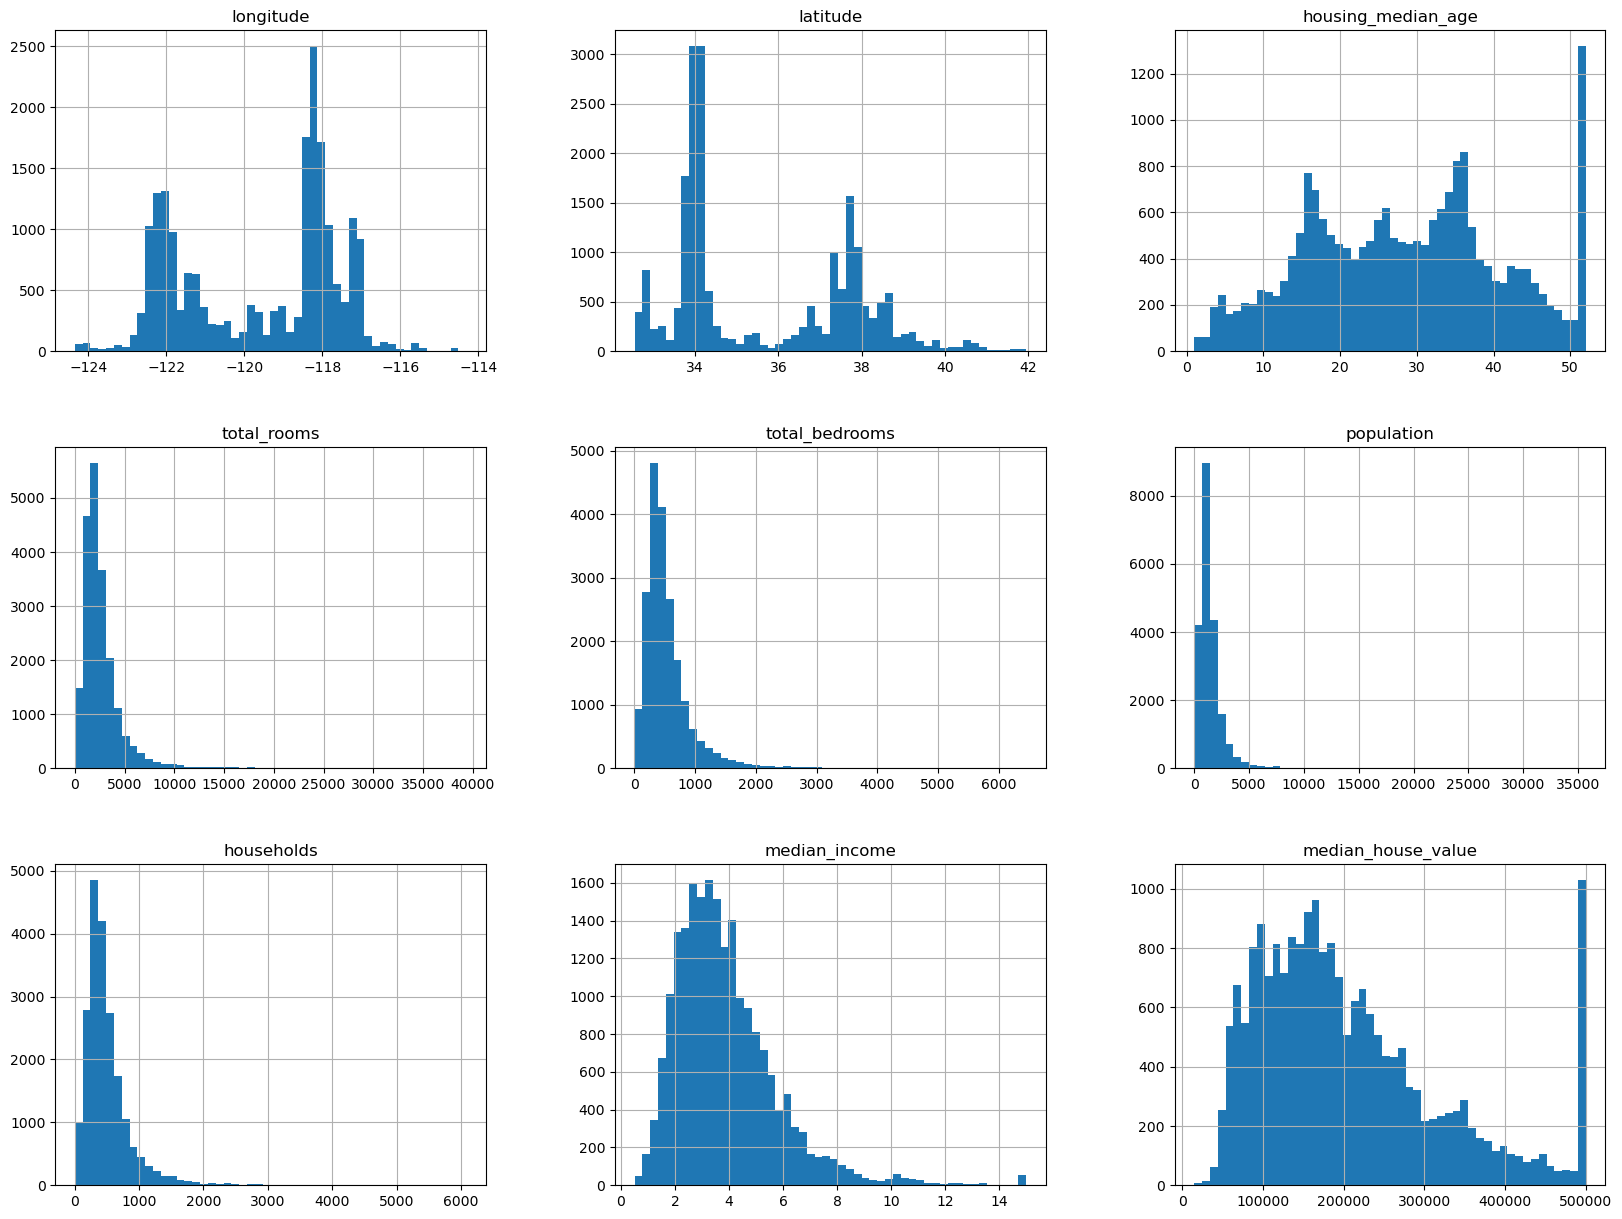

In [203]:
display(rawDf.sample(5))
display(rawDf.describe())
rawDf.hist(figsize=(20,15), bins=50)
rawDf.info()

<Axes: xlabel='population', ylabel='Density'>

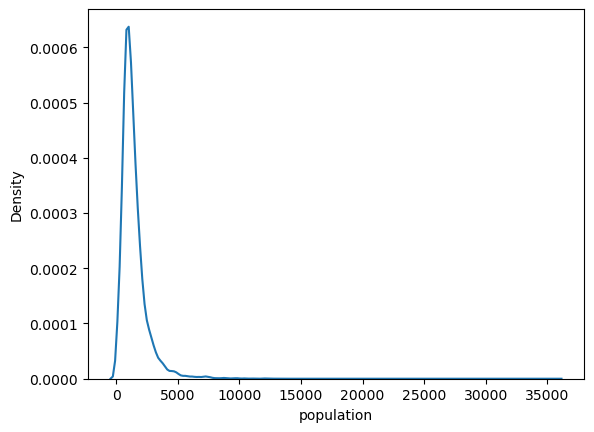

In [204]:
sns.kdeplot(data=rawDf, x="population")

<Axes: xlabel='latitude', ylabel='longitude'>

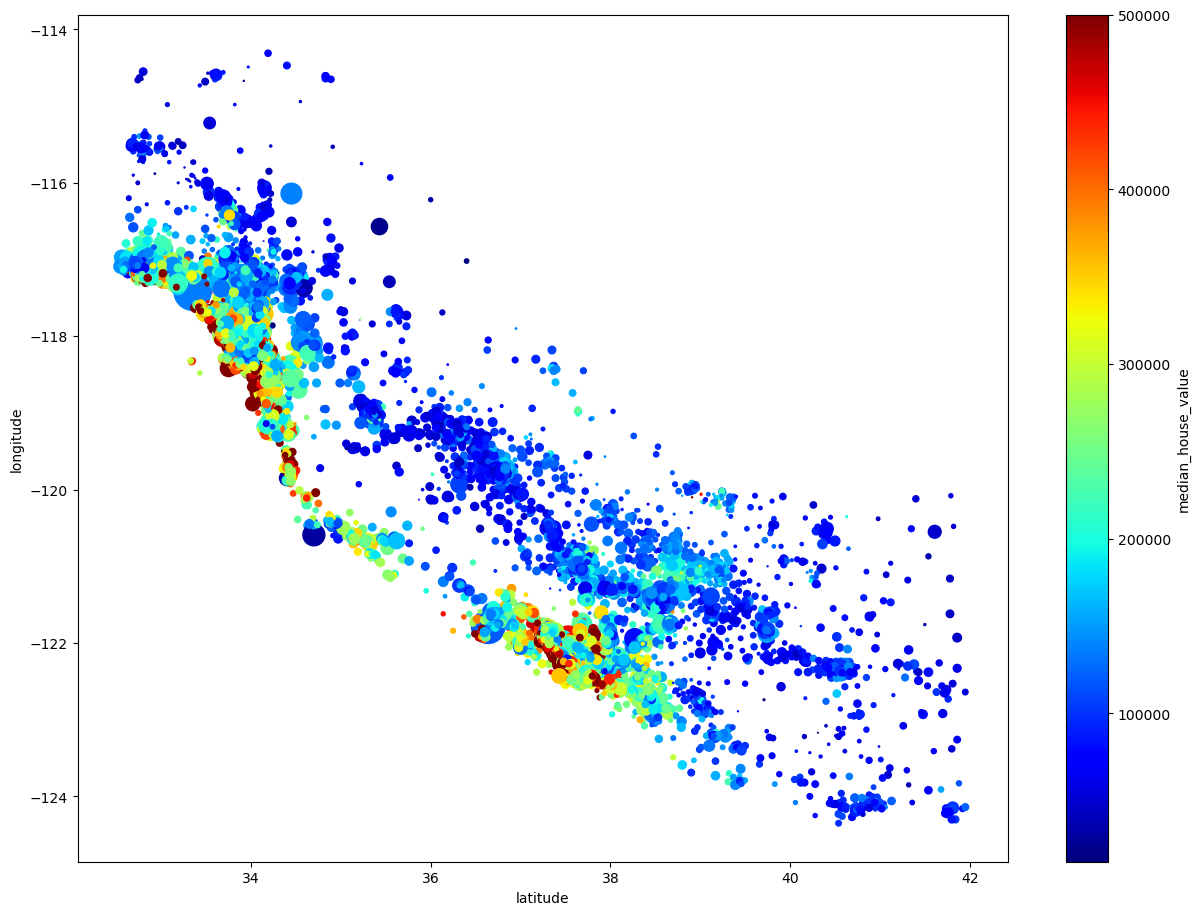

In [205]:
rawDf.plot(kind="scatter", x="latitude", y="longitude", c="median_house_value", s=rawDf["population"]/50, cmap="jet",sharex=False,alpha=1, figsize=(15,11))

In [206]:
rawDf.select_dtypes(include=np.number).corr()["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

median_income_cat
0       12
1      147
2      663
3     1635
4     2348
5     2598
6     2720
7     2430
8     2086
9     1512
10    1289
11     838
12     709
13     454
14     260
15     249
16     690
Name: count, dtype: int64


median_income_cat
0     0.000581
1     0.007122
2     0.032122
3     0.079215
4     0.113760
5     0.125872
6     0.131783
7     0.117733
8     0.101066
9     0.073256
10    0.062452
11    0.040601
12    0.034351
13    0.021996
14    0.012597
15    0.012064
16    0.033430
Name: proportion, dtype: float64

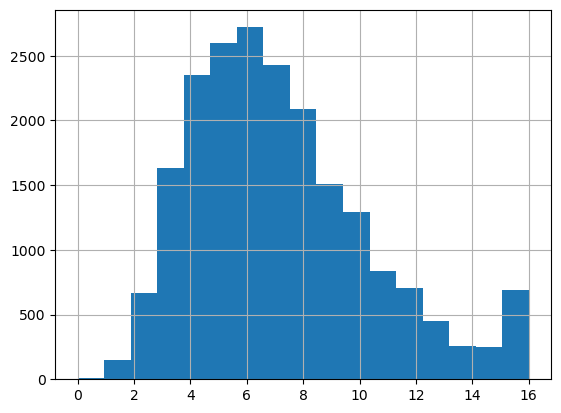

In [207]:
rawDf["median_income_cat"] = pd.cut(rawDf["median_income"], bins=[0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, np.inf], labels=np.arange(0,17,1))
print(rawDf["median_income_cat"].value_counts().sort_index())
rawDf["median_income_cat"].hist(bins=17)
rawDf["median_income_cat"].value_counts(normalize=True).sort_index()

In [208]:
spliter = StratifiedShuffleSplit(test_size=0.2, random_state=67, n_splits=1)
trainSet = []
testSet = []
for trainIndex, testIndex in spliter.split(rawDf, rawDf["median_income_cat"]):
    trainSet = rawDf.iloc[trainIndex]
    testSet = rawDf.iloc[testIndex]

median_income_cat
0       10
1      118
2      531
3     1308
4     1878
5     2078
6     2176
7     1944
8     1669
9     1210
10    1031
11     670
12     567
13     363
14     208
15     199
16     552
Name: count, dtype: int64
median_income_cat
0     0.000606
1     0.007146
2     0.032158
3     0.079215
4     0.113735
5     0.125848
6     0.131783
7     0.117733
8     0.101078
9     0.073280
10    0.062439
11    0.040577
12    0.034339
13    0.021984
14    0.012597
15    0.012052
16    0.033430
Name: proportion, dtype: float64
median_income_cat
0       2
1      29
2     132
3     327
4     470
5     520
6     544
7     486
8     417
9     302
10    258
11    168
12    142
13     91
14     52
15     50
16    138
Name: count, dtype: int64
median_income_cat
0     0.000484
1     0.007025
2     0.031977
3     0.079215
4     0.113857
5     0.125969
6     0.131783
7     0.117733
8     0.101017
9     0.073159
10    0.062500
11    0.040698
12    0.034399
13    0.022045
14    0.012597
15    

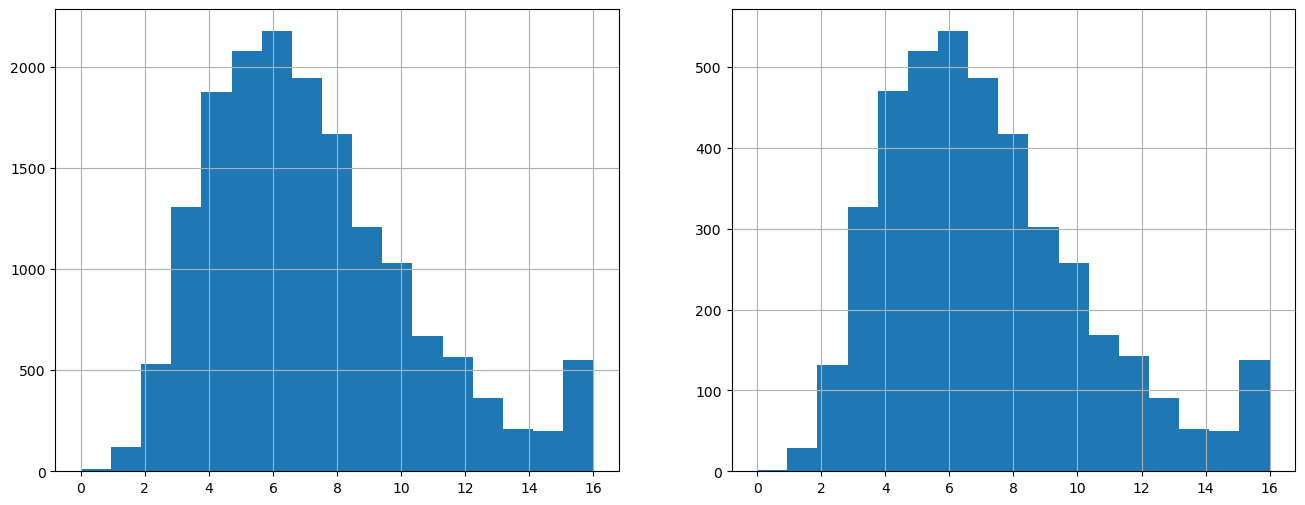

In [209]:
print(trainSet["median_income_cat"].value_counts().sort_index())
print(trainSet["median_income_cat"].value_counts(normalize=True).sort_index())
print(testSet["median_income_cat"].value_counts().sort_index())
print(testSet["median_income_cat"].value_counts(normalize=True).sort_index())
plt.figure(figsize=(16,6))
plt.subplot(1, 2, 1)
trainSet["median_income_cat"].hist(bins=17)
plt.subplot(1, 2, 2)
testSet["median_income_cat"].hist(bins=17)
plt.show()

In [210]:
trainSet.drop(columns=["median_income_cat"], inplace=True)
testSet.drop(columns=["median_income_cat"], inplace=True)
display(testSet)
display(trainSet)

/tmp/ipykernel_15929/3880526545.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trainSet.drop(columns=["median_income_cat"], inplace=True)
/tmp/ipykernel_15929/3880526545.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testSet.drop(columns=["median_income_cat"], inplace=True)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
15872,-121.84,36.59,34.0,3852.0,733.0,1661.0,696.0,4.3269,221300.0,<1H OCEAN
11551,-122.32,37.94,46.0,1901.0,295.0,833.0,352.0,5.5196,210800.0,NEAR BAY
10720,-122.44,37.80,52.0,1006.0,291.0,445.0,257.0,2.7717,500000.0,NEAR BAY
6429,-122.40,37.72,37.0,971.0,248.0,647.0,208.0,2.1187,239300.0,NEAR BAY
14730,-117.65,33.60,15.0,5736.0,NaN,2529.0,762.0,6.4114,278700.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
18298,-118.09,33.98,37.0,1270.0,272.0,1092.0,274.0,3.5000,160700.0,<1H OCEAN
5844,-118.40,34.18,32.0,3724.0,899.0,1912.0,791.0,3.5711,312700.0,<1H OCEAN
12689,-116.53,33.88,5.0,4423.0,763.0,1906.0,667.0,4.6855,125200.0,INLAND
13390,-122.27,37.87,30.0,1465.0,439.0,862.0,425.0,1.7778,268800.0,NEAR BAY


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
17819,-122.97,38.53,48.0,3939.0,860.0,1257.0,571.0,2.1165,98700.0,<1H OCEAN
7672,-115.60,33.04,31.0,314.0,61.0,152.0,56.0,3.3472,91700.0,INLAND
17459,-117.97,33.71,26.0,2553.0,405.0,1337.0,411.0,5.3737,252900.0,<1H OCEAN
11228,-122.23,37.78,52.0,472.0,146.0,415.0,126.0,2.6429,71300.0,NEAR BAY
806,-117.20,32.76,40.0,581.0,157.0,298.0,156.0,2.4000,255000.0,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...,...
19637,-117.99,33.71,17.0,1600.0,458.0,1803.0,432.0,2.7865,216700.0,<1H OCEAN
2374,-122.06,37.70,33.0,3906.0,790.0,1912.0,770.0,3.5187,209400.0,NEAR BAY
1535,-118.09,34.57,4.0,9761.0,1683.0,4970.0,1535.0,4.5266,142900.0,INLAND
2544,-118.36,34.11,35.0,3946.0,695.0,1361.0,620.0,6.5195,500001.0,<1H OCEAN


In [211]:
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, nCluster=10, gamma=1, randomState=None):
        self.nCluster=nCluster
        self.gamma=gamma
        self.randomState=randomState


    def fit(self, X, y=None, sampleWeight=None):
        self.kMeans = KMeans(random_state=self.randomState, n_clusters=self.nCluster)
        self.kMeans.fit(X, sample_weight=sampleWeight)
        return self
    
    def transform(self, X):
        return rbf_kernel(X, self.kMeans.cluster_centers_, gamma=self.gamma)
    
    def get_feature_names_out(self, names=None):
        return [f"cluster_{i}_similarity" for i in range(self.nCluster)]


In [212]:
def featureRatio(X):
    return X[:,[0]] / X[:,[1]]
def featureRatioName(function_transformer, feature_names_in):
    return["ratio"]

ratioPipeline = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("ratio", FunctionTransformer(featureRatio, feature_names_out=featureRatioName)),
        ("scale", StandardScaler())
    ]
)

logPipeline= Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log, feature_names_out="one-to-one")),
        ("scale", StandardScaler())
    ]
)

clusterization = ClusterSimilarity(nCluster=10, gamma=1.0, randomState=67)

catPipeline = Pipeline(

        [
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore"))
        ]

)

defaultNumPipeline = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]
)


In [213]:
preprocessing = ColumnTransformer(
    [
        ("bedrooms", ratioPipeline, ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratioPipeline, ["total_rooms", "households"]),
        ("people_per_house", ratioPipeline, ["population", "households"]),
        ("people_per_rooms", ratioPipeline, ["population", "total_rooms"]),
        ("people_per_bedrooms", ratioPipeline, ["population", "total_bedrooms"]),
        ("bedroom_per_households", ratioPipeline, ["households", "total_bedrooms"]),
        ("log", logPipeline, ["population", "households", "total_rooms", "total_bedrooms"]),
        ("geo_cluster", clusterization,["longitude", "latitude"]),
        ("cat", catPipeline, ["ocean_proximity"]),
    ],
    remainder = defaultNumPipeline
)

In [214]:
trainSetX = trainSet.drop(columns=["median_house_value"])
trainSetY = trainSet["median_house_value"]

preprocessedData = preprocessing.fit_transform(trainSetX)

In [215]:
print(preprocessedData)
preprocessedDataDF = pd.DataFrame(preprocessedData, columns=preprocessing.get_feature_names_out(), index=np.arange(0, preprocessedData.shape[0], 1))
preprocessedDataDF

[[ 0.06983093  0.6182818  -0.08086153 ...  0.          1.53139685
  -0.92307285]
 [-0.2939389   0.07301103 -0.03255257 ...  0.          0.18372192
  -0.27507825]
 [-0.83260313  0.32828916  0.01819319 ...  0.         -0.21265306
   0.79192513]
 ...
 [-0.624217    0.39048077  0.01675619 ...  0.         -1.95670298
   0.34590561]
 [-0.56817655  0.39282795 -0.08144925 ...  0.          0.5008219
   1.39521773]
 [-0.20727511 -0.18336792 -0.04227066 ...  0.         -0.21265306
  -1.44512261]]


,bedrooms__ratio,rooms_per_house__ratio,people_per_house__ratio,people_per_rooms__ratio,people_per_bedrooms__ratio,bedroom_per_households__ratio,log__population,log__households,log__total_rooms,log__total_bedrooms,...,geo_cluster__cluster_7_similarity,geo_cluster__cluster_8_similarity,geo_cluster__cluster_9_similarity,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,remainder__housing_median_age,remainder__median_income
0,0.069831,0.618282,-0.080862,-0.096333,-0.119667,-1.916157,0.152433,0.501721,0.867847,0.973292,...,4.646938e-01,3.214316e-23,1.115045e-02,1.0,0.0,0.0,0.0,0.0,1.531397,-0.923073
1,-0.293939,0.073011,-0.032553,-0.043179,-0.034384,-0.176052,-2.724340,-2.690557,-2.522992,-2.687827,...,8.690722e-31,1.690717e-02,4.227142e-23,0.0,1.0,0.0,0.0,0.0,0.183722,-0.275078
2,-0.832603,0.328289,0.018193,-0.030412,0.032625,0.486776,0.236452,0.049701,0.286473,-0.068630,...,9.987152e-17,6.446778e-01,6.880341e-12,1.0,0.0,0.0,0.0,0.0,-0.212653,0.791925
3,1.445457,-0.712883,0.022018,0.084152,-0.005354,-0.552859,-1.356631,-1.575711,-1.976570,-1.480303,...,9.666023e-01,3.714965e-17,2.118268e-01,0.0,0.0,0.0,1.0,0.0,1.848497,-0.645910
4,0.854369,-0.722034,-0.108285,-0.033888,-0.083535,0.341692,-1.807612,-1.282095,-1.698025,-1.379798,...,8.882562e-24,2.069007e-01,6.435096e-18,0.0,0.0,0.0,0.0,1.0,0.897197,-0.773803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16507,1.096654,-0.730757,0.104902,0.163947,0.085231,-0.003475,0.643638,0.118209,-0.339957,0.101529,...,1.188305e-16,6.292803e-01,7.758875e-12,1.0,0.0,0.0,0.0,0.0,-0.926128,-0.570301
16508,-0.173215,-0.152657,-0.054327,-0.041430,-0.040307,0.211931,0.723569,0.912781,0.856568,0.855824,...,8.808057e-01,3.418858e-16,3.120028e-01,0.0,0.0,0.0,1.0,0.0,0.342272,-0.184779
16509,-0.624217,0.390481,0.016756,-0.035093,0.003801,-0.216945,2.024379,1.861231,2.084425,1.902251,...,1.923105e-13,4.351975e-01,7.401488e-09,0.0,1.0,0.0,0.0,0.0,-1.956703,0.345906
16510,-0.568177,0.392828,-0.081449,-0.088023,-0.078552,-0.353751,0.260679,0.614907,0.870227,0.678555,...,6.428813e-14,3.751539e-01,1.378514e-09,1.0,0.0,0.0,0.0,0.0,0.500822,1.395218


In [216]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'people_per_rooms__ratio',
       'people_per_bedrooms__ratio', 'bedroom_per_households__ratio',
       'log__population', 'log__households', 'log__total_rooms',
       'log__total_bedrooms', 'geo_cluster__cluster_0_similarity',
       'geo_cluster__cluster_1_similarity',
       'geo_cluster__cluster_2_similarity',
       'geo_cluster__cluster_3_similarity',
       'geo_cluster__cluster_4_similarity',
       'geo_cluster__cluster_5_similarity',
       'geo_cluster__cluster_6_similarity',
       'geo_cluster__cluster_7_similarity',
       'geo_cluster__cluster_8_similarity',
       'geo_cluster__cluster_9_similarity',
       'cat__ocean_proximity_<1H OCEAN', 'cat__ocean_proximity_INLAND',
       'cat__ocean_proximity_ISLAND', 'cat__ocean_proximity_NEAR BAY',
       'cat__ocean_proximity_NEAR OCEAN', 'remainder__housing_median_age',
       'remainder__median_income'], dtype=object)

In [219]:
print("""Correlation:
remainder__median_house_value        1.000000
remainder__median_income             0.688109
cat__ocean_proximity_<1H OCEAN       0.250814
geo_cluster__cluster_1_similarity    0.249174
geo_cluster__cluster_7_similarity    0.211645
geo_cluster__cluster_0_similarity    0.193922
cat__ocean_proximity_NEAR BAY        0.163679
log__total_rooms                     0.154311
cat__ocean_proximity_NEAR OCEAN      0.152034
rooms_per_house__ratio               0.149851
remainder__housing_median_age        0.104933
bedroom_per_households__ratio        0.079946
log__households                      0.068688
geo_cluster__cluster_6_similarity    0.065894
log__total_bedrooms                  0.047525
geo_cluster__cluster_8_similarity    0.037419
cat__ocean_proximity_ISLAND          0.021014
people_per_bedrooms__ratio          -0.015338
geo_cluster__cluster_4_similarity   -0.018488
people_per_house__ratio             -0.019597
log__population                     -0.025210
people_per_rooms__ratio             -0.029258
geo_cluster__cluster_9_similarity   -0.111993
geo_cluster__cluster_5_similarity   -0.159696
geo_cluster__cluster_2_similarity   -0.194329
bedrooms__ratio                     -0.228632
geo_cluster__cluster_3_similarity   -0.260647
cat__ocean_proximity_INLAND         -0.486610
Name: remainder__median_house_value, dtype: float64""")

Correlation:
remainder__median_house_value        1.000000
remainder__median_income             0.688109
cat__ocean_proximity_<1H OCEAN       0.250814
geo_cluster__cluster_1_similarity    0.249174
geo_cluster__cluster_7_similarity    0.211645
geo_cluster__cluster_0_similarity    0.193922
cat__ocean_proximity_NEAR BAY        0.163679
log__total_rooms                     0.154311
cat__ocean_proximity_NEAR OCEAN      0.152034
rooms_per_house__ratio               0.149851
remainder__housing_median_age        0.104933
bedroom_per_households__ratio        0.079946
log__households                      0.068688
geo_cluster__cluster_6_similarity    0.065894
log__total_bedrooms                  0.047525
geo_cluster__cluster_8_similarity    0.037419
cat__ocean_proximity_ISLAND          0.021014
people_per_bedrooms__ratio          -0.015338
geo_cluster__cluster_4_similarity   -0.018488
people_per_house__ratio             -0.019597
log__population                     -0.025210
people_per_rooms__rat